In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import scanpy as sc

import os

import seaborn as sns



# Load Data

## Load entropy results

In [10]:
# Load Entropy value for each barcode on atac (if any barcode has invalid entropy value, it's not included in the file)
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_wDNAdebrisflag_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,log10_Entropy
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,-2.285327
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,-0.690589


In [14]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['invalid_entropy'] = union_cell_info['Entropy'].isna()
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,invalid_entropy
atac_bc,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,False
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,False


In [15]:
union_cell_info['Entropy'].isna().sum()

np.int64(22)

## Given some barcodes could have invalid entropy and does not have a record -- load fragment file 

In [5]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']



In [18]:
union_cell_info.groupby(['invalid_entropy', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)

_2set_identified_by_atac_SC,both,cr_only,entropy_only,none
invalid_entropy,,,,
False,1865,81,236,180
True,0,13,0,9


In [19]:
union_cell_info.groupby(['DNA_debris', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)

_2set_identified_by_atac_SC,both,cr_only,entropy_only,none
DNA_debris,,,,
NO,1865,72,236,189
YES,0,22,0,0


In [26]:
bc_DNAdebris_list = union_cell_info.loc[union_cell_info['DNA_debris'] == 'YES'].index.tolist()
bc_invalid_entropy_list = union_cell_info.loc[union_cell_info['invalid_entropy']].index.tolist()
bc_entropy_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_SC'] == 'entropy_only'].index.tolist()
bc_cr_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_SC'] == 'cr_only'].index.tolist()
bc_common_list = union_cell_info.loc[union_cell_info['_2set_identified_by_atac_SC'] == 'both'].index.tolist()

In [31]:
individual_bc_frag_subdir = os.path.join(Union_cell_subdir, 'cmp_SC', 'individual_bc_frag')
if not os.path.exists(individual_bc_frag_subdir):
    os.makedirs(individual_bc_frag_subdir)

for l,n in zip([bc_DNAdebris_list, bc_invalid_entropy_list, bc_entropy_list, bc_cr_list, bc_common_list], 
             ['DNA_debris', 'invalid_entropy', 'entropy_only', 'cr_only', 'common']):
    bc_df = pd.DataFrame({'atac_BC': l})
    bc_df.to_csv(os.path.join(individual_bc_frag_subdir, f'{n}_bc_list.tsv'), sep='\t', index=True)

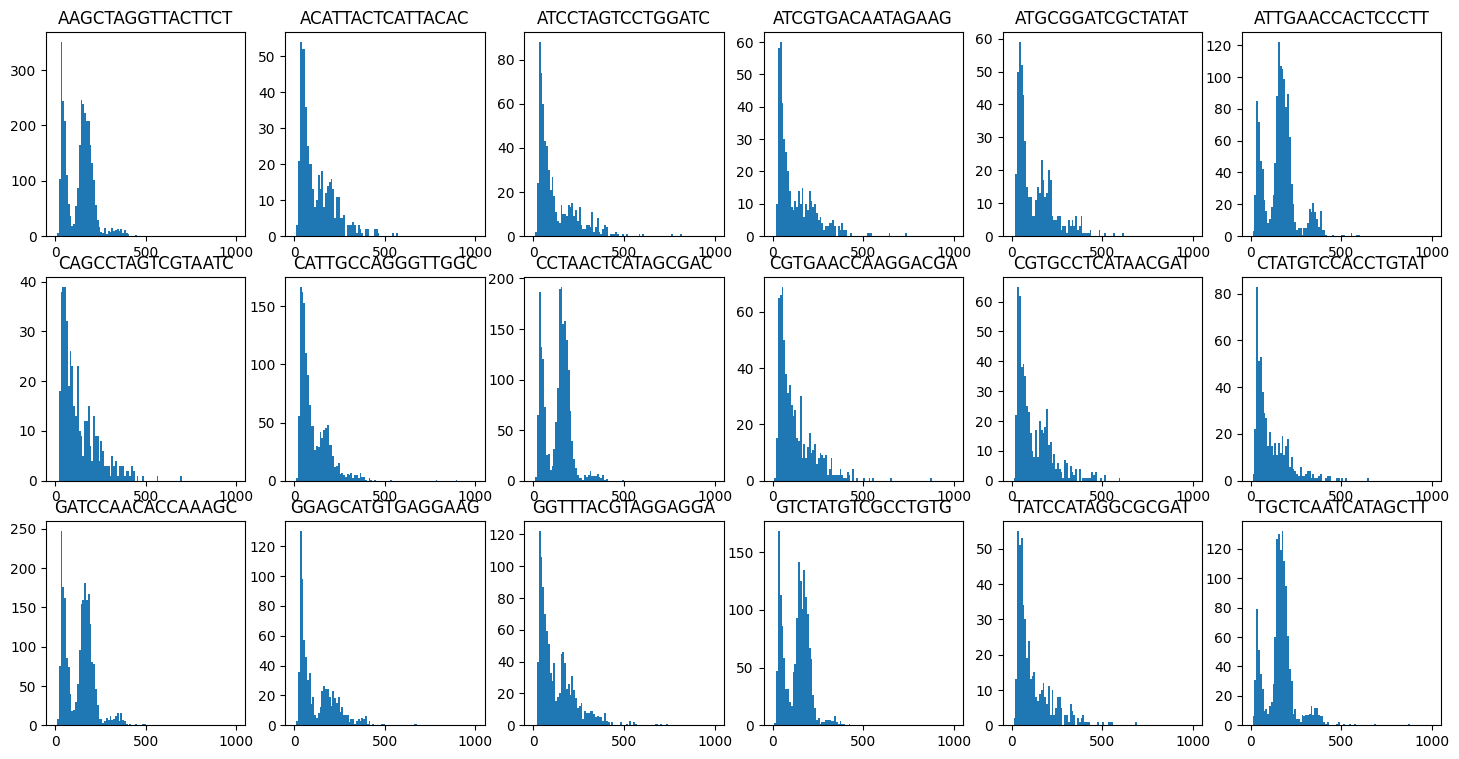

In [27]:
total_sub_fig = len(bc_DNAdebris_list)
ncol = 6
nrow = 3
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*3, nrow*3))
ax = ax.flatten()

for i, bc in enumerate(bc_invalid_entropy_list):
    if i >= nrow*ncol:
        break
    _ = ax[i].hist(frag.loc[frag['atac_bc'] == bc, 'frag_length'], bins=100, range=(0, 1000))
    ax[i].set_title(bc)

Text(0.5, 1.02, 'Fragment length distribution of DNA debris barcodes')

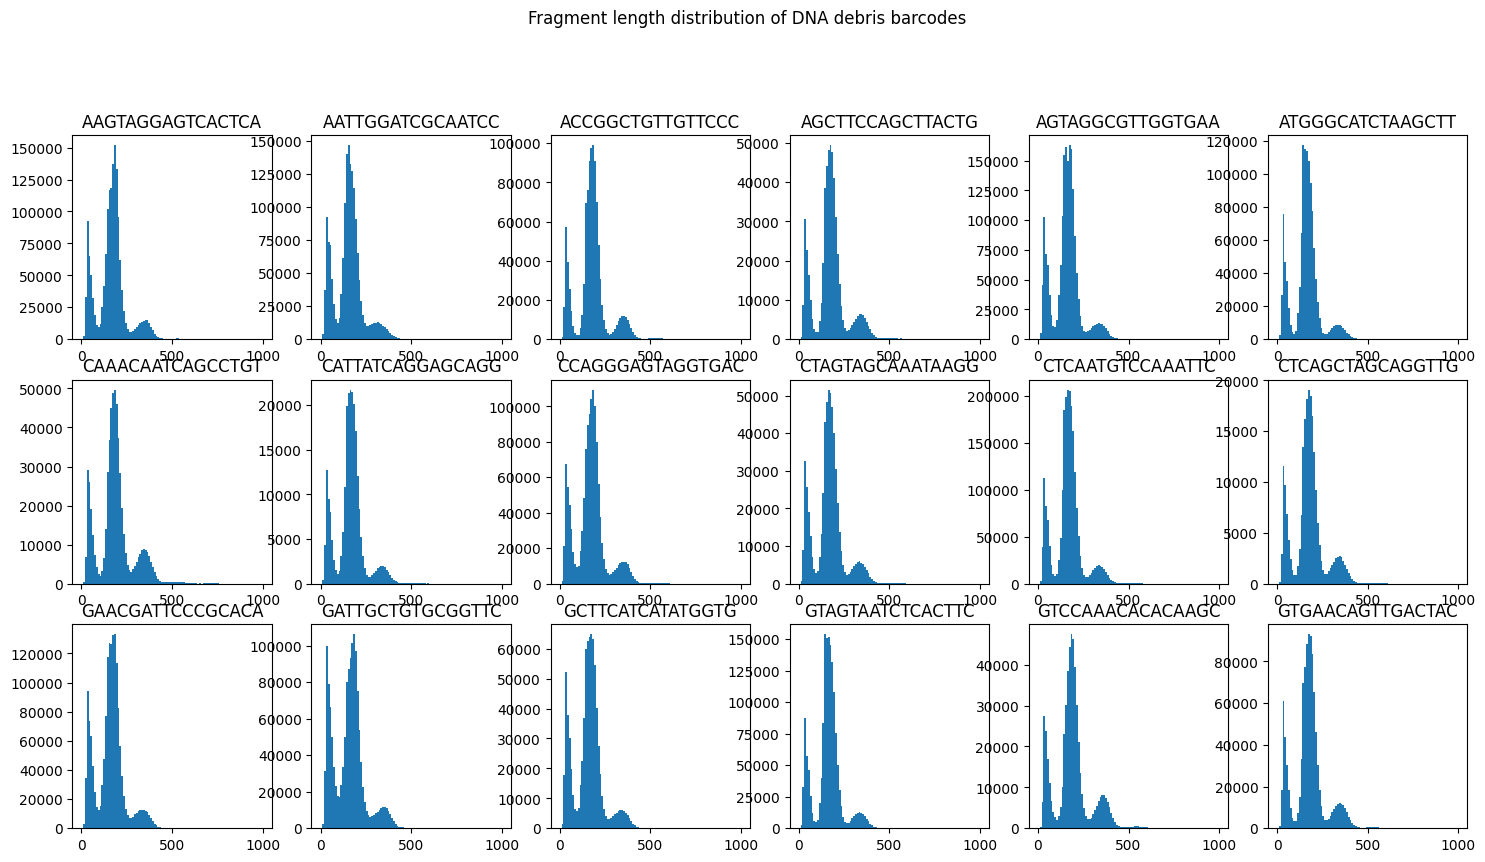

In [33]:
total_sub_fig = len(bc_DNAdebris_list)
ncol = 6
nrow = 3
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*3, nrow*3))
ax = ax.flatten()

for i, bc in enumerate(bc_DNAdebris_list):
    if i >= nrow*ncol:
        break
    _ = ax[i].hist(frag.loc[frag['atac_bc'] == bc, 'frag_length'], bins=100, range=(0, 1000))
    ax[i].set_title(bc)
fig.suptitle('Fragment length distribution of DNA debris barcodes', y=1.02)